# Market path diagnostics

This notebook compares the runtime market path modes used by Monte Carlo:

- `stochastic`
- `stochastic_overdispersion`

It uses the clean market series from `cashflow/market/data/quarterly_market_clean.parquet` and the current `MarketPathModel` implementation from `hedonic_runtime.py`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'market' / 'hedonic_residualization.py').exists():
        REPO_ROOT = candidate
        break
else:
    raise FileNotFoundError('Could not locate repo root from the notebook working directory')

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from monte_carlo.hedonic_runtime import MarketPathModel
from monte_carlo.mc_cashflow_engine import (
    GlobalScenario,
    LocalScenarioPath,
    ProjectConfig,
    QuarterContext,
    QuarterId,
    Scenario,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlelocation'] = 'center'

In [2]:
clean_path = REPO_ROOT / 'market' / 'data' / 'quarterly_market_clean.parquet'
clean = pd.read_parquet(clean_path).copy()
clean['quarter_norm'] = clean['quarter'].astype('string')
clean['quarter_order'] = clean['quarter_norm'].map(lambda q: int(q[:4]) * 4 + int(q[-1]))
clean['market_log_price'] = pd.to_numeric(clean['market_log_level_q'], errors='coerce')
clean['raw_deal_median'] = pd.to_numeric(clean['actual_log_price_median'], errors='coerce')
clean = clean.sort_values('quarter_order').drop_duplicates('quarter_norm', keep='last').reset_index(drop=True)

anchor_quarter = '2023Q1'
anchor_order = int(anchor_quarter[:4]) * 4 + int(anchor_quarter[-1])
forecast_horizon = 12

history = clean.loc[clean['quarter_order'] <= anchor_order, ['quarter_norm', 'quarter_order', 'market_log_price']].copy()
history = history.dropna(subset=['market_log_price']).reset_index(drop=True)

anchor_idx = int(clean.index[clean['quarter_norm'] == anchor_quarter][0])
forecast_orders = np.arange(anchor_order, anchor_order + forecast_horizon, dtype=int)
forecast_labels = [f"{o // 4 - (1 if o % 4 == 0 else 0)}Q{4 if o % 4 == 0 else o % 4}" for o in forecast_orders]

print(f'Clean rows: {len(clean)}')
print(f'Observed rows used for fit: {len(history)}')
print(f'Anchor quarter: {anchor_quarter} (row {anchor_idx})')
print(f'Forecast horizon: {forecast_horizon} quarters')
clean[['quarter_norm', 'raw_deal_median', 'market_log_price']].head()

Clean rows: 45
Observed rows used for fit: 33
Anchor quarter: 2023Q1 (row 32)
Forecast horizon: 12 quarters


,quarter_norm,raw_deal_median,market_log_price
0,2015Q1,12.510335,12.733139
1,2015Q2,12.194887,12.225860
2,2015Q3,12.804537,12.353107
3,2015Q4,12.018603,11.979400
4,2016Q1,11.982435,11.934835


In [3]:
def order_to_quarter(order: int) -> str:
    year, quarter = divmod(int(order), 4)
    if quarter == 0:
        year -= 1
        quarter = 4
    return f'{year}Q{quarter}'


def order_to_qid(order: int) -> QuarterId:
    year, quarter = divmod(int(order), 4)
    if quarter == 0:
        year -= 1
        quarter = 4
    return QuarterId(year=year, quarter=quarter)


def build_project_config(*, horizon_quarters: int) -> ProjectConfig:
    return ProjectConfig(
        name='market_path_diagnostics',
        start_year=2023,
        start_quarter=1,
        horizon_quarters=horizon_quarters,
        rns_quarter_index=0,
        rvz_quarter_index=0,
        sellable_area_sqm=1.0,
        avg_unit_area_sqm=1.0,
        initial_remaining_lots=1,
        key_rate_annual=0.0,
        full_rate_spread_before_rvz=0.0,
        full_rate_spread_after_rvz=0.0,
        privileged_rate_annual=0.0,
        reserve_fee_annual=0.0,
    )


def ewm_baseline(history_df: pd.DataFrame, *, horizon_quarters: int) -> pd.DataFrame:
    series = history_df['market_log_price'].astype(float)
    orders = history_df['quarter_order'].astype(int)
    smoothed = series.ewm(span=6, adjust=False).mean()
    anchor_level = float(series.iloc[-1])
    anchor_slope = float(smoothed.iloc[-1] - smoothed.iloc[-2]) if len(smoothed) >= 2 else 0.0
    anchor_order = int(orders.iloc[-1])
    future_orders = np.arange(anchor_order, anchor_order + horizon_quarters, dtype=int)
    trend = anchor_level + anchor_slope * (future_orders - anchor_order)
    return pd.DataFrame(
        {
            'quarter_order': future_orders,
            'quarter_norm': [order_to_quarter(o) for o in future_orders],
            'trend_baseline': trend,
            'anchor_level': anchor_level,
            'anchor_slope': anchor_slope,
            'anchor_order': anchor_order,
        }
    )


def simulate_mode(mode: str, *, n_paths: int = 120, horizon_quarters: int = 12, seed_base: int = 1000) -> pd.DataFrame:
    config = build_project_config(horizon_quarters=horizon_quarters)
    scenario = Scenario(global_state=GlobalScenario(), local_path=LocalScenarioPath())
    model_history = history.copy().reset_index(drop=True)
    model_history = model_history.rename(columns={'market_log_price': 'market_log_price'})

    rows = []
    for path_idx in range(n_paths):
        model = MarketPathModel(mode=mode, market_index_table=model_history, seed=seed_base + path_idx)
        model.initialize_path(config=config, scenario=scenario)
        for idx, order in enumerate(forecast_orders[:horizon_quarters]):
            qid = order_to_qid(order)
            ctx = QuarterContext(
                index=idx,
                quarter_id=qid,
                is_pre_rns=False,
                is_post_rvz=False,
                is_rvz_quarter=False,
                rvz_effective_index=0,
            )
            value = model.get_market_log_price(ctx=ctx, config=config, scenario=scenario)
            rows.append(
                {
                    'path': path_idx,
                    'idx': idx,
                    'quarter_order': order,
                    'quarter_norm': order_to_quarter(order),
                    'market_log_price': value,
                }
            )
    return pd.DataFrame(rows)


def plot_mode(mode: str, *, n_paths: int = 120, horizon_quarters: int = 12) -> tuple[pd.DataFrame, pd.DataFrame]:
    baseline = ewm_baseline(history, horizon_quarters=horizon_quarters)
    paths = simulate_mode(mode, n_paths=n_paths, horizon_quarters=horizon_quarters)
    wide = paths.pivot(index='idx', columns='path', values='market_log_price').sort_index(axis=1)
    path_values = wide.to_numpy(dtype=float).T
    mean = np.nanmean(path_values, axis=0)
    p10 = np.nanpercentile(path_values, 10, axis=0)
    p90 = np.nanpercentile(path_values, 90, axis=0)

    fig, ax = plt.subplots(figsize=(15, 6.5))
    x_all = np.arange(len(clean))
    ax.plot(x_all, clean['market_log_price'], color='black', linewidth=2.25, label='clean market index')
    ax.plot(x_all, clean['raw_deal_median'], color='0.75', linewidth=1.5, label='raw deal median')

    forecast_x = np.arange(anchor_idx, anchor_idx + horizon_quarters)
    for path in path_values:
        ax.plot(forecast_x, path, color='#d95f5f', alpha=0.18, linewidth=1.0)
    ax.plot(forecast_x, mean, color='#d62728', linewidth=2.2, label=f'{mode} mean')
    ax.fill_between(forecast_x, p10, p90, color='#d95f5f', alpha=0.15, label='P10-P90')
    ax.plot(forecast_x, baseline['trend_baseline'], color='0.25', linestyle='--', linewidth=2.1, label='trend baseline (EWM, fit to 2023Q1)')

    ax.axvline(anchor_idx, color='0.5', linestyle=':', linewidth=1.1)
    ax.scatter([anchor_idx], [clean.loc[anchor_idx, 'market_log_price']], color='black', s=25, zorder=6)

    tick_idx = np.arange(0, len(clean), 4)
    if tick_idx[-1] != len(clean) - 1:
        tick_idx = np.append(tick_idx, len(clean) - 1)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(clean.loc[tick_idx, 'quarter_norm'], rotation=45, ha='right')
    ax.set_xlim(-0.5, len(clean) - 0.5)
    ax.set_ylabel('log(market)')
    ax.set_xlabel('quarter')
    ax.set_title(f'Market log-price forecast: {mode}')
    ax.legend(loc='upper left', ncol=2, frameon=True)
    fig.tight_layout()
    plt.show()
    return baseline, paths


summary = ewm_baseline(history, horizon_quarters=forecast_horizon)[['anchor_level', 'anchor_slope', 'anchor_order']].head(1)
summary

,anchor_level,anchor_slope,anchor_order
0,12.6142,0.012662,8093


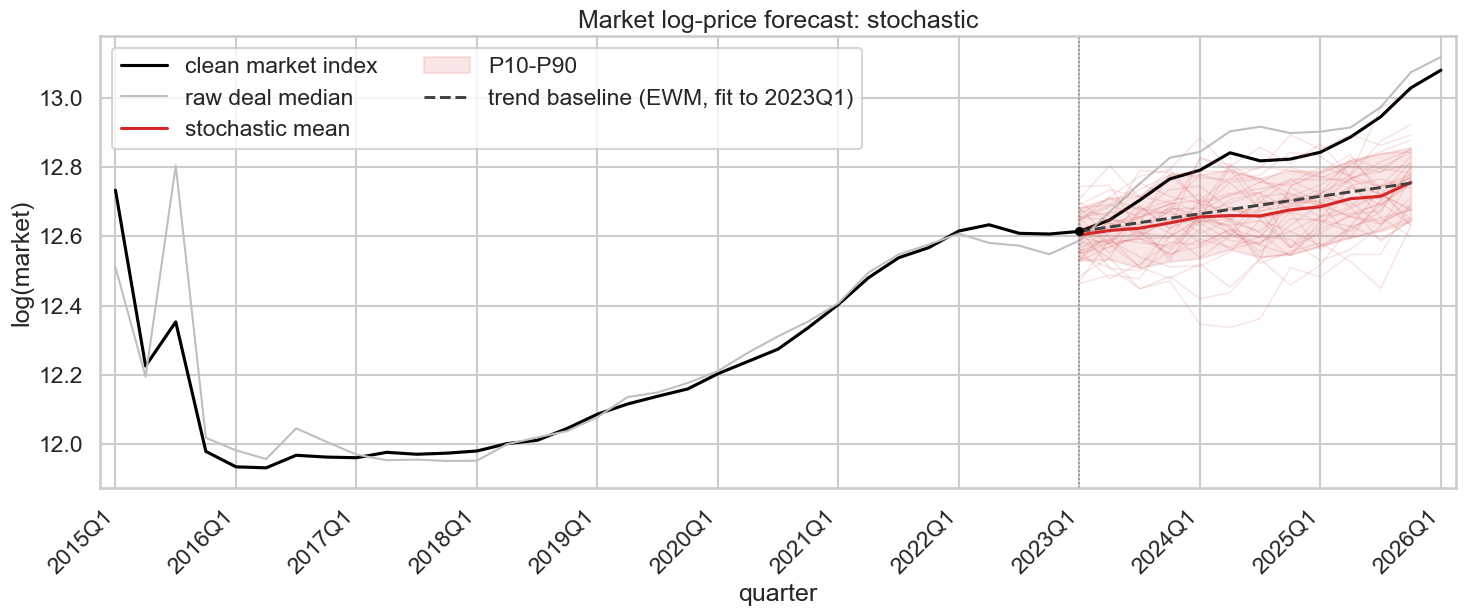

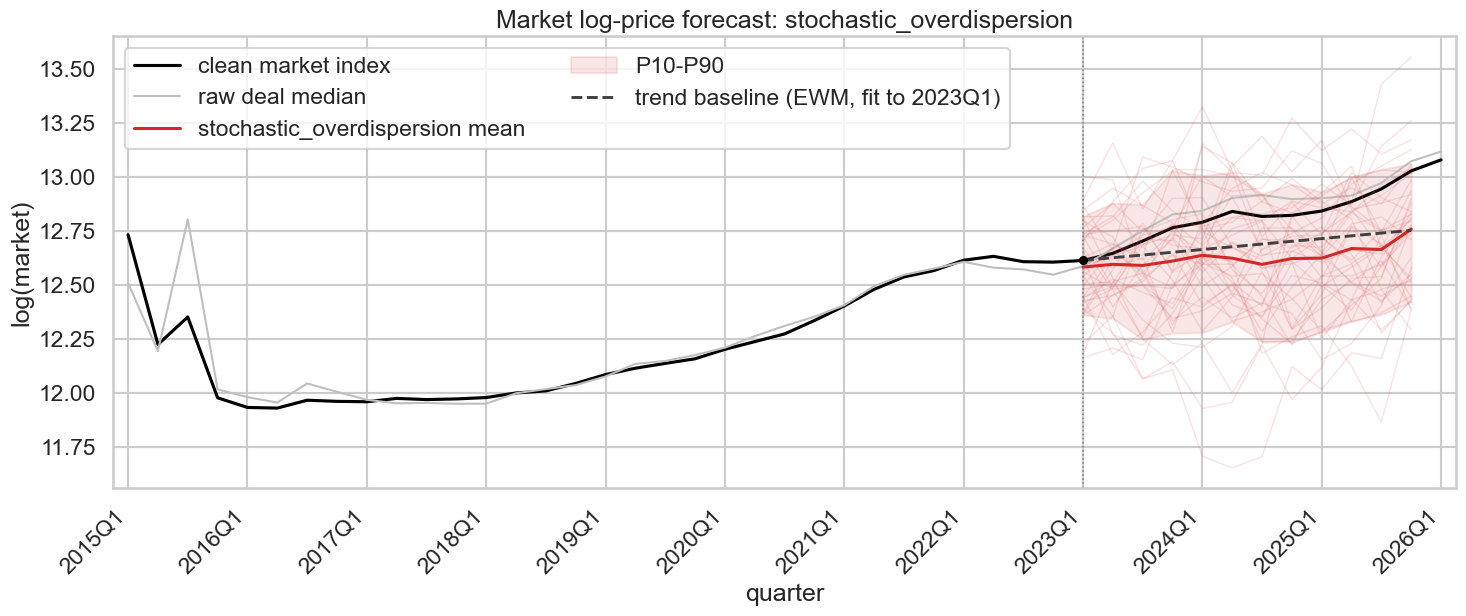

In [4]:
baseline_stochastic, paths_stochastic = plot_mode('stochastic', n_paths=40, horizon_quarters=forecast_horizon)
baseline_stochastic_overdispersion, paths_overdispersion = plot_mode('stochastic_overdispersion', n_paths=40, horizon_quarters=forecast_horizon)